In [11]:
# Run this cell FIRST to install JAX into the exact Python this kernel uses
import sys
print("Kernel Python:", sys.executable)
!{sys.executable} -m pip install jax matplotlib -q
print("Done! Now run the cells below.")

Kernel Python: <local-python>
Done! Now run the cells below.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# JAX Quickstart Tutorial
Based on the [official JAX quickstart](https://docs.jax.dev/en/latest/quickstart.html).

**Sections:**
1. JAX vs NumPy
2. JAX Arrays — devices & sharding
3. Just-in-time compilation with `jax.jit`
4. Automatic differentiation with `jax.grad`
5. Auto-vectorization with `jax.vmap`
6. Pseudorandom numbers
7. Debugging

## 1. JAX vs NumPy

JAX provides `jax.numpy` which closely mirrors the NumPy API — almost anything done with `numpy` can be done with `jax.numpy` (`jnp`).

**Key difference:** JAX arrays are **immutable** — you cannot change them in-place.

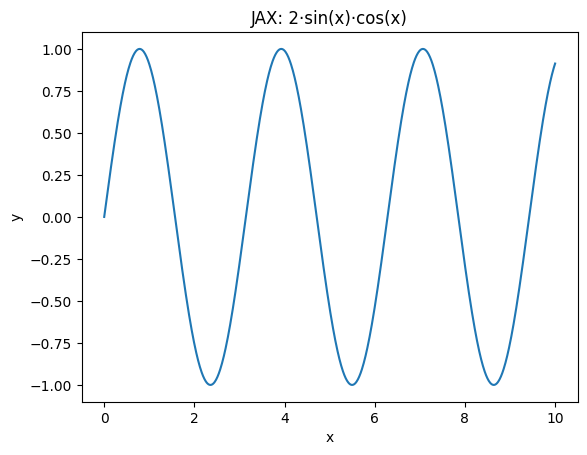

In [12]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# JAX numpy mirrors the NumPy API — just swap np → jnp
x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp, y_jnp)
plt.title("JAX: 2·sin(x)·cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [13]:
# Arrays are different Python types
x_np = np.linspace(0, 10, 1000)
print("NumPy type:", type(x_np))    # numpy.ndarray
print("JAX type:  ", type(x_jnp))   # jaxlib._jax.ArrayImpl

NumPy type: <class 'numpy.ndarray'>
JAX type:   <class 'jaxlib._jax.ArrayImpl'>


In [14]:
# NumPy arrays are mutable — in-place assignment works
x_mut = np.arange(10)
x_mut[0] = 10
print("NumPy (mutable):", x_mut)

NumPy (mutable): [10  1  2  3  4  5  6  7  8  9]


In [15]:
# JAX arrays are IMMUTABLE — use .at[].set() to get an updated copy
x_immut = jnp.arange(10)
y_immut = x_immut.at[0].set(10)   # returns a NEW array
print("JAX original: ", x_immut)   # unchanged
print("JAX updated:  ", y_immut)

# This would raise TypeError: JAX arrays are immutable
# x_immut[0] = 10

JAX original:  [0 1 2 3 4 5 6 7 8 9]
JAX updated:   [10  1  2  3  4  5  6  7  8  9]


## 2. JAX Arrays — Devices & Sharding

`jax.Array` objects know which device(s) they live on via `.devices()` and `.sharding`.

In [16]:
import jax

x = jnp.arange(5)
print("Is jax.Array?", isinstance(x, jax.Array))   # True
print("Devices:      ", x.devices())               # {CpuDevice(id=0)}
print("Sharding:     ", x.sharding)                # SingleDeviceSharding(...)

Is jax.Array? True
Devices:       {CpuDevice(id=0)}
Sharding:      SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=unpinned_host)


## 3. Just-in-Time Compilation with `jax.jit`

`jax.jit` compiles a function using XLA, fusing operations and eliminating temporary allocations.

**Limitation:** JIT requires **static (known) array shapes** at compile time.

In [17]:
from jax import jit

def norm(X):
    """Row-wise normalisation: subtract column mean, divide by column std."""
    X = X - X.mean(0)
    return X / X.std(0)

norm_compiled = jit(norm)   # JIT-compiled version

np.random.seed(1701)
X = jnp.array(np.random.rand(10_000, 10))

# Both produce the same result
print("Results match:", np.allclose(norm(X), norm_compiled(X), atol=1e-6))

Results match: True


In [18]:
import timeit

# Warm up the JIT cache first
_ = norm_compiled(X).block_until_ready()

t1 = timeit.timeit(lambda: norm(X).block_until_ready(), number=100)
t2 = timeit.timeit(lambda: norm_compiled(X).block_until_ready(), number=100)
print(f"Eager  (100 runs): {t1*1000:.1f} ms")
print(f"JIT    (100 runs): {t2*1000:.1f} ms")

Eager  (100 runs): 14.7 ms
JIT    (100 runs): 13.2 ms


In [19]:
# JIT requires static shapes — dynamic output shapes fail at compile time
def get_negatives(x):
    return x[x < 0]   # output shape depends on runtime values

x_rand = jnp.array(np.random.randn(10))
print("Eager (works):", get_negatives(x_rand))

# Uncomment to see NonConcreteBooleanIndexError:
# jit(get_negatives)(x_rand)

Eager (works): [-0.10570311 -0.59403396 -0.8680282  -0.23489487]


## 4. Automatic Differentiation with `jax.grad`

`jax.grad` transforms a scalar-output function into its gradient function. It composes freely with `jit` and other transforms.

In [20]:
from jax import grad

def sum_logistic(x):
    """Sum of sigmoid(x_i) — a scalar output."""
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
derivative_fn = grad(sum_logistic)
print("grad(sum_logistic):", derivative_fn(x_small))

grad(sum_logistic): [0.25       0.19661197 0.10499357]


In [21]:
# Verify with finite differences
def first_finite_differences(f, x, eps=1e-3):
    return jnp.array([
        (f(x + eps * v) - f(x - eps * v)) / (2 * eps)
        for v in jnp.eye(len(x))
    ])

print("Finite diff approx:", first_finite_differences(sum_logistic, x_small))

Finite diff approx: [0.24998187 0.1964569  0.10502338]


In [22]:
# grad and jit compose arbitrarily — higher-order derivatives
print("3rd-order derivative at 1.0:", grad(jit(grad(jit(grad(sum_logistic)))))(1.0))

3rd-order derivative at 1.0: -0.0353256


In [23]:
from jax import jacobian

# Full Jacobian matrix for vector-valued functions
print("Jacobian of exp(x_small):\n", jacobian(jnp.exp)(x_small))

Jacobian of exp(x_small):
 [[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [24]:
from jax import jacfwd, jacrev

# Hessian = forward-over-reverse AD
def hessian(fun):
    return jit(jacfwd(jacrev(fun)))

print("Hessian of sum_logistic:\n", hessian(sum_logistic)(x_small))

Hessian of sum_logistic:
 [[-0.         -0.         -0.        ]
 [-0.         -0.09085776 -0.        ]
 [-0.         -0.         -0.07996249]]


## 5. Auto-vectorization with `jax.vmap`

`jax.vmap` transforms a function that operates on a single example into one that efficiently handles a batch — without writing manual loops.

In [25]:
from jax import random, vmap

key = random.key(1701)
key1, key2 = random.split(key)
mat = random.normal(key1, (150, 100))
batched_x = random.normal(key2, (10, 100))

def apply_matrix(x):
    """Matrix-vector product: mat @ x  (single vector)."""
    return jnp.dot(mat, x)

In [26]:
# Naive Python loop
def naively_batched_apply_matrix(v_batched):
    return jnp.stack([apply_matrix(v) for v in v_batched])

print("Naive output shape:", naively_batched_apply_matrix(batched_x).shape)

Naive output shape: (10, 150)


In [27]:
# Manual batching using jnp.dot semantics
@jit
def batched_apply_matrix(batched_x):
    return jnp.dot(batched_x, mat.T)

np.testing.assert_allclose(
    naively_batched_apply_matrix(batched_x),
    batched_apply_matrix(batched_x), atol=1e-4, rtol=1e-4)
print("Manual batching matches naive: True")

Manual batching matches naive: True


In [28]:
# vmap — automatic, composable, no manual rewrite needed
@jit
def vmap_batched_apply_matrix(batched_x):
    return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(
    naively_batched_apply_matrix(batched_x),
    vmap_batched_apply_matrix(batched_x), atol=1e-4, rtol=1e-4)
print("vmap batching matches naive: True")

vmap batching matches naive: True


In [29]:
# Warm up JIT caches
_ = batched_apply_matrix(batched_x).block_until_ready()
_ = vmap_batched_apply_matrix(batched_x).block_until_ready()

t_naive  = timeit.timeit(lambda: naively_batched_apply_matrix(batched_x).block_until_ready(), number=100)
t_manual = timeit.timeit(lambda: batched_apply_matrix(batched_x).block_until_ready(), number=100)
t_vmap   = timeit.timeit(lambda: vmap_batched_apply_matrix(batched_x).block_until_ready(), number=100)
print(f"Naive   (100 runs): {t_naive*1000:.1f} ms")
print(f"Manual  (100 runs): {t_manual*1000:.1f} ms")
print(f"vmap    (100 runs): {t_vmap*1000:.1f} ms")

Naive   (100 runs): 30.6 ms
Manual  (100 runs): 0.9 ms
vmap    (100 runs): 1.9 ms


## 6. Pseudorandom Numbers

Unlike NumPy, JAX has **no hidden global RNG state**. You must pass an explicit `key` to every random function, and `split()` it to get independent samples.

In [30]:
from jax import random

key = random.key(43)
print("Initial key:", key)

# Same key → same sample (deterministic)
print("Draw 1 (same key):", random.normal(key))
print("Draw 2 (same key):", random.normal(key))   # identical!

Initial key: Array((), dtype=key<fry>) overlaying:
[ 0 43]
Draw 1 (same key): 0.07520543
Draw 2 (same key): 0.07520543


In [31]:
# To get different samples — split the key first
for i in range(3):
    new_key, subkey = random.split(key)
    val = random.normal(subkey)
    print(f"draw {i}: {val:.6f}")
    key = new_key   # advance to the next key

draw 0: -1.913363
draw 1: -1.474984
draw 2: -0.367038


## 7. Debugging

JAX offers two levels of inspection inside JIT-compiled functions:
- `print()` — runs at **trace time**, shows abstract tracer values
- `jax.debug.print()` — runs at **runtime**, shows actual values

Use `jax.disable_jit()` to run code eagerly for step-by-step debugging.

In [32]:
import jax

# Python print() inside jit shows tracer objects — NOT runtime values
@jax.jit
def f_print(x):
    print("print(x) ->", x)   # trace-time: shows JitTracer
    y = jnp.sin(x)
    print("print(y) ->", y)   # trace-time
    return y

_ = f_print(2.)

print(x) -> Traced<~float32[]>with<DynamicJaxprTrace>
print(y) -> Traced<~float32[]>with<DynamicJaxprTrace>


In [33]:
# jax.debug.print() runs at runtime — shows real values
@jax.jit
def f_debug(x):
    jax.debug.print("jax.debug.print(x) -> {x}", x=x)
    y = jnp.sin(x)
    jax.debug.print("jax.debug.print(y) -> {y}", y=y)
    return y

_ = f_debug(2.)

jax.debug.print(x) -> 2.0
jax.debug.print(y) -> 0.9092974066734314


In [34]:
# Disable JIT globally — runs eagerly, compatible with pdb / print
with jax.disable_jit():
    result = f_debug(2.)
print("Eager result:", result)

jax.debug.print(x) -> 2.0
jax.debug.print(y) -> 0.9092974066734314
Eager result: 0.9092974


In [35]:
# Detect NaNs automatically during development:
# jax.config.update("jax_debug_nans", True)
# _ = jnp.log(jnp.array(-1.0))   # would raise FloatingPointError

print("Tutorial complete! 🎉")

Tutorial complete! 🎉
